In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

df = pd.read_sql_query(
    "SELECT * FROM processed_air_quality",
    conn
)

df.head()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91,14,17,Friday
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91,14,17,Friday
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91,15,17,Friday
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20,16,17,Friday
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83,18,17,Friday


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         112 non-null    int64  
 1   timestamp  112 non-null    object 
 2   aqi        112 non-null    int64  
 3   pm2_5      112 non-null    float64
 4   pm10       112 non-null    float64
 5   co         112 non-null    float64
 6   no2        112 non-null    float64
 7   o3         112 non-null    float64
 8   so2        112 non-null    float64
 9   hour       112 non-null    int64  
 10  day        112 non-null    int64  
 11  weekday    112 non-null    object 
dtypes: float64(6), int64(4), object(2)
memory usage: 10.6+ KB


In [4]:
df.describe()

,id,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000
mean,56.500000,3.169643,40.898661,45.678393,640.158661,16.005625,50.419732,6.348571,16.758929,21.830357
std,32.475632,0.642186,15.151214,17.393854,193.561497,7.533680,33.698615,1.361482,4.819715,3.107354
min,1.000000,2.000000,14.650000,16.680000,262.580000,1.890000,2.670000,3.050000,0.000000,17.000000
25%,28.750000,3.000000,32.017500,34.600000,506.652500,10.900000,18.402500,5.540000,14.000000,19.000000
50%,56.500000,3.000000,35.420000,38.900000,651.530000,15.755000,49.850000,6.190000,17.500000,22.000000
75%,84.250000,3.000000,49.242500,55.790000,797.285000,21.582500,71.500000,7.165000,21.000000,24.000000
max,112.000000,5.000000,80.590000,94.680000,1093.890000,30.130000,134.230000,9.520000,23.000000,27.000000


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 112
Columns: 12


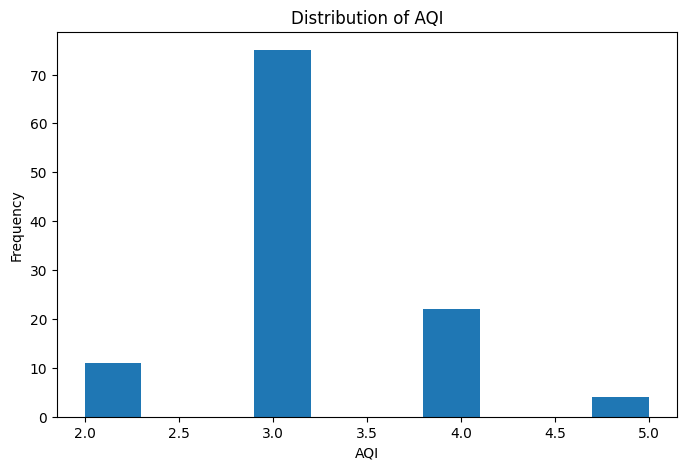

In [6]:
#aqi distribution
plt.figure(figsize=(8,5))

plt.hist(df["aqi"], bins=10)

plt.title("Distribution of AQI")

plt.xlabel("AQI")

plt.ylabel("Frequency")

plt.show()

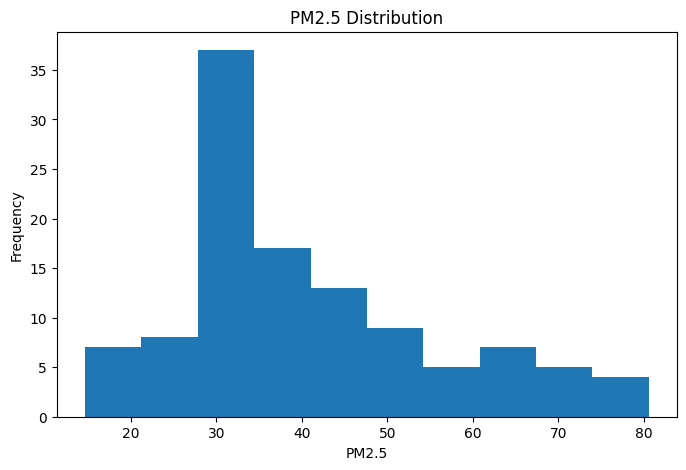

In [7]:
#PM 2.5 distribution
plt.figure(figsize=(8,5))

plt.hist(df["pm2_5"], bins=10)

plt.title("PM2.5 Distribution")

plt.xlabel("PM2.5")

plt.ylabel("Frequency")

plt.show()

In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

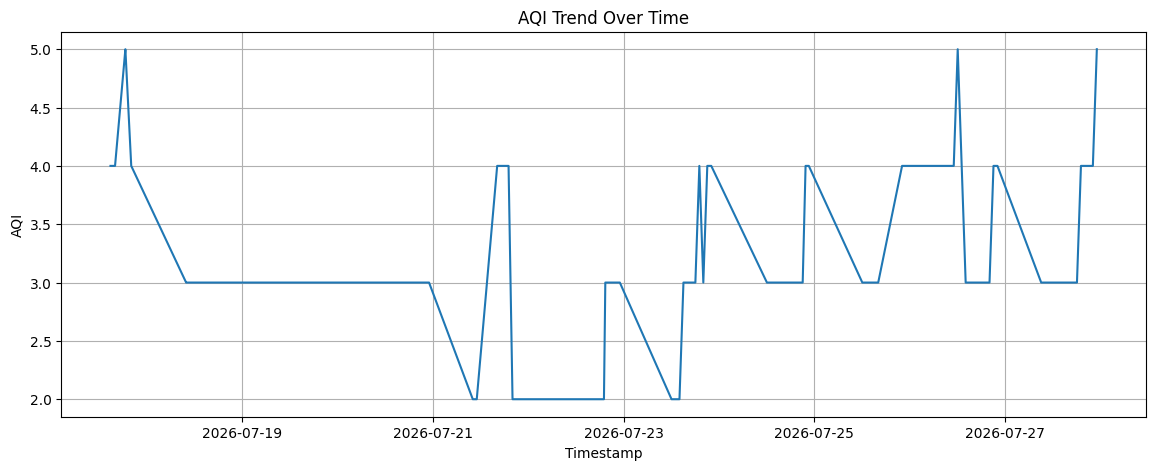

In [9]:
#AQI trend over time
plt.figure(figsize=(14,5))

plt.plot(df["timestamp"], df["aqi"])

plt.title("AQI Trend Over Time")

plt.xlabel("Timestamp")

plt.ylabel("AQI")

plt.grid(True)

plt.show()

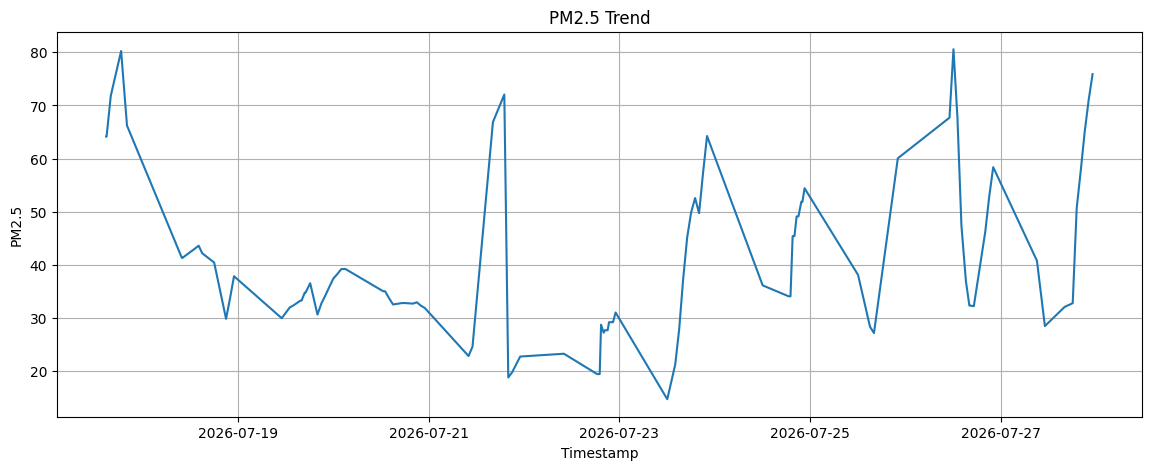

In [10]:
plt.figure(figsize=(14,5))

plt.plot(df["timestamp"], df["pm2_5"])

plt.title("PM2.5 Trend")

plt.xlabel("Timestamp")

plt.ylabel("PM2.5")

plt.grid(True)

plt.show()

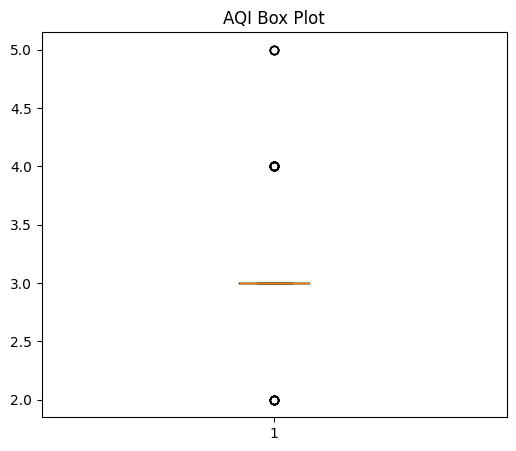

In [11]:
plt.figure(figsize=(6,5))

plt.boxplot(df["aqi"])

plt.title("AQI Box Plot")

plt.show()

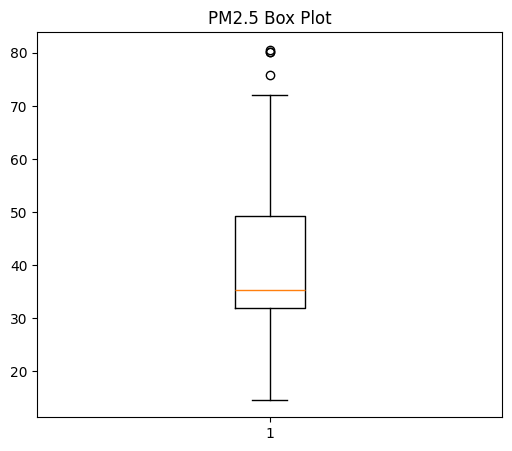

In [12]:
plt.figure(figsize=(6,5))

plt.boxplot(df["pm2_5"])

plt.title("PM2.5 Box Plot")

plt.show()

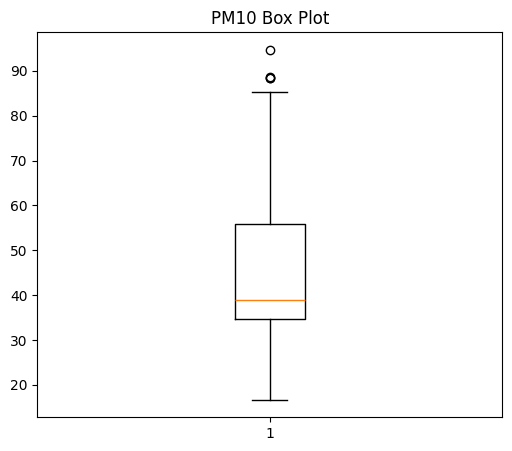

In [13]:
plt.figure(figsize=(6,5))

plt.boxplot(df["pm10"])

plt.title("PM10 Box Plot")

plt.show()

In [14]:
correlation = df.corr(numeric_only=True)

correlation

,id,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day
id,1.000000,0.108642,0.057064,0.112295,-0.141805,-0.114213,0.115632,0.006168,0.234286,0.991441
aqi,0.108642,1.000000,0.908776,0.898571,0.359374,0.080152,0.301439,0.256539,0.161777,0.118389
pm2_5,0.057064,0.908776,1.000000,0.985283,0.370137,0.045099,0.372670,0.329922,0.079200,0.073948
pm10,0.112295,0.898571,0.985283,1.000000,0.455422,0.140516,0.275703,0.412645,0.148730,0.122977
co,-0.141805,0.359374,0.370137,0.455422,1.000000,0.896532,-0.684363,0.680986,0.063137,-0.162816
no2,-0.114213,0.080152,0.045099,0.140516,0.896532,1.000000,-0.845018,0.650233,0.156103,-0.164608
o3,0.115632,0.301439,0.372670,0.275703,-0.684363,-0.845018,1.000000,-0.378246,-0.013616,0.151300
so2,0.006168,0.256539,0.329922,0.412645,0.680986,0.650233,-0.378246,1.000000,0.302373,-0.039432
hour,0.234286,0.161777,0.079200,0.148730,0.063137,0.156103,-0.013616,0.302373,1.000000,0.140411
day,0.991441,0.118389,0.073948,0.122977,-0.162816,-0.164608,0.151300,-0.039432,0.140411,1.000000


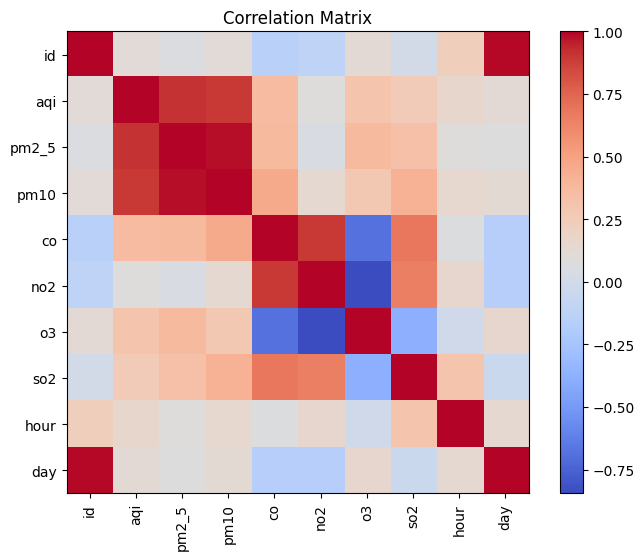

In [15]:
#correlation heatmap
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

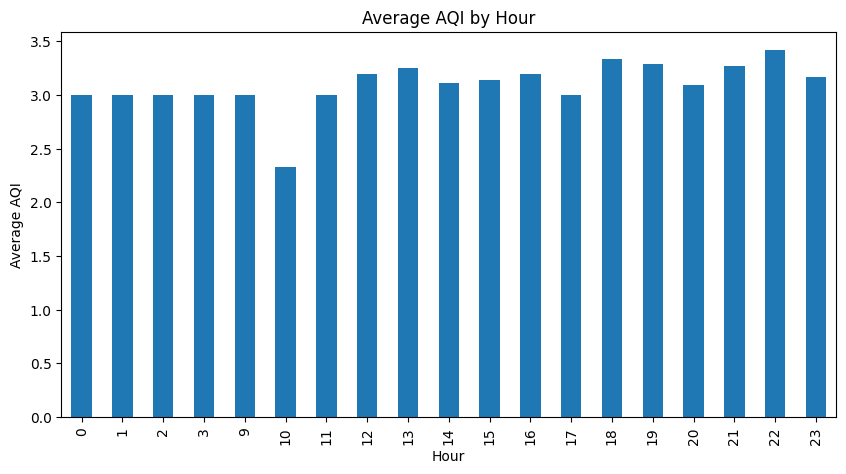

In [16]:
#avg aqi by hour
hourly = df.groupby("hour")["aqi"].mean()

hourly.plot(kind="bar", figsize=(10,5))

plt.title("Average AQI by Hour")

plt.xlabel("Hour")

plt.ylabel("Average AQI")

plt.show()

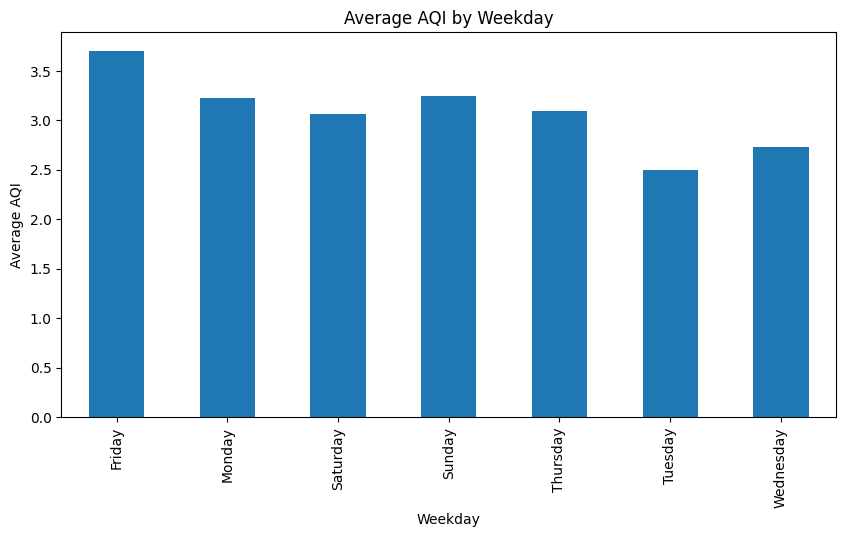

In [17]:
weekday = df.groupby("weekday")["aqi"].mean()

weekday.plot(kind="bar", figsize=(10,5))

plt.title("Average AQI by Weekday")

plt.xlabel("Weekday")

plt.ylabel("Average AQI")

plt.show()

In [18]:
summary = df.describe()

summary.to_csv("../data/eda_summary.csv")

In [19]:
conn.close()